Loaded 3 files; combined shape: (1350, 1844)
Velocities loaded, n-columns=1350 n_rows=1844. Now reading metadata
Done. now doing graphics
time elapsed = 24.531439304351807 seconds


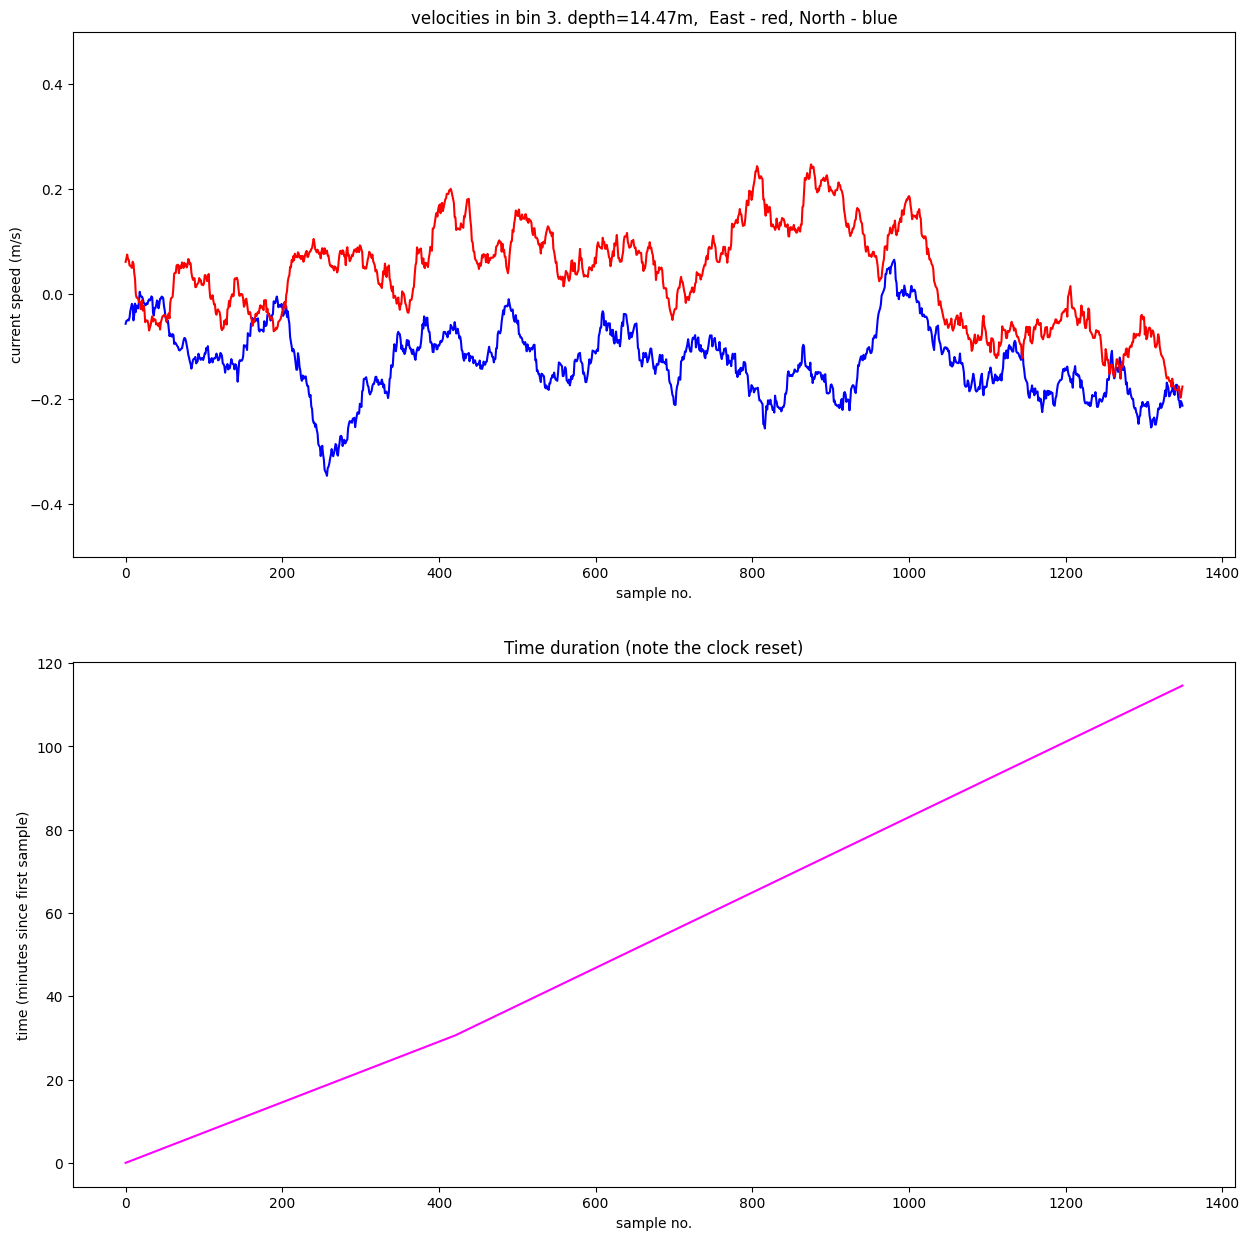

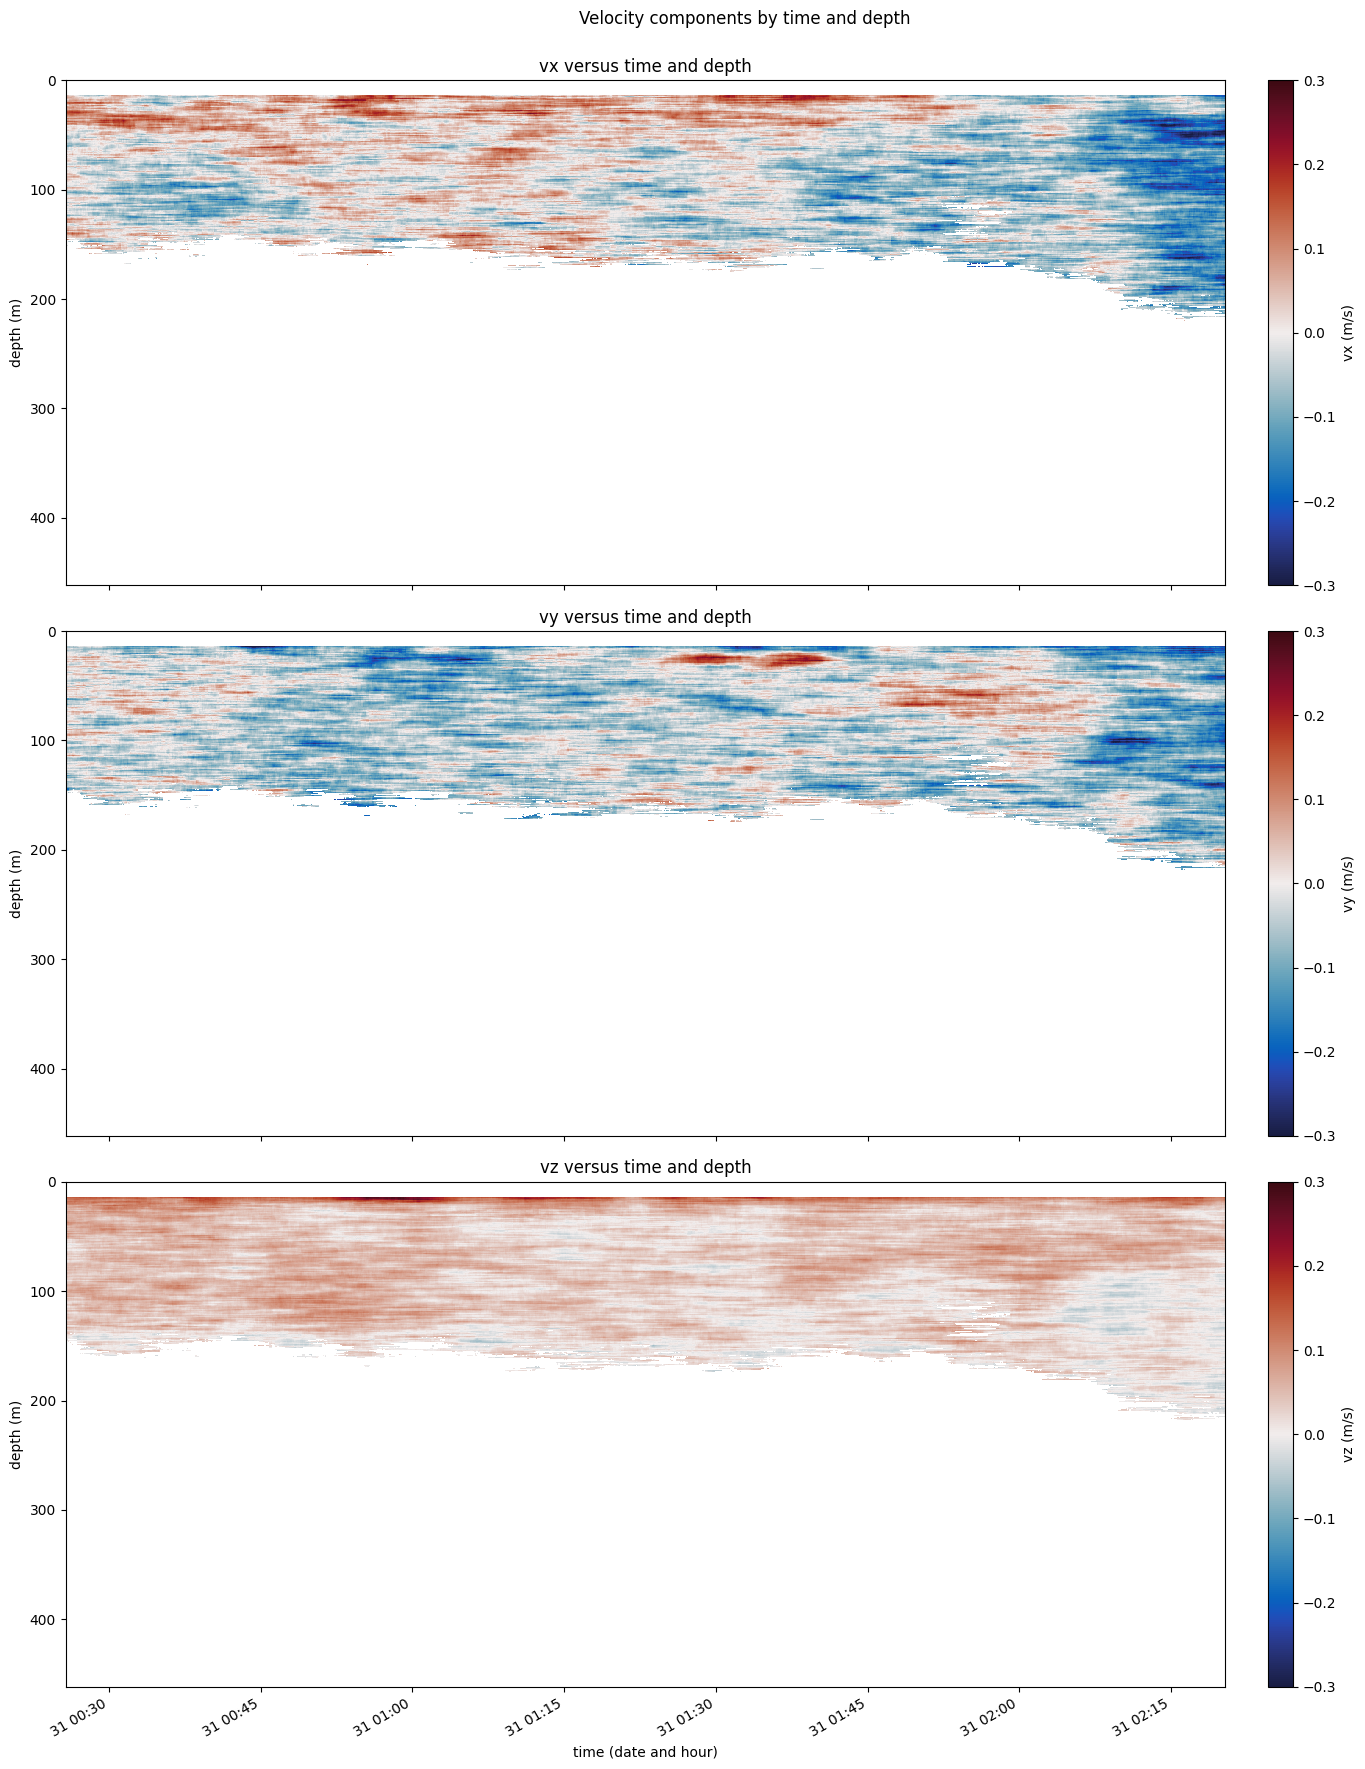

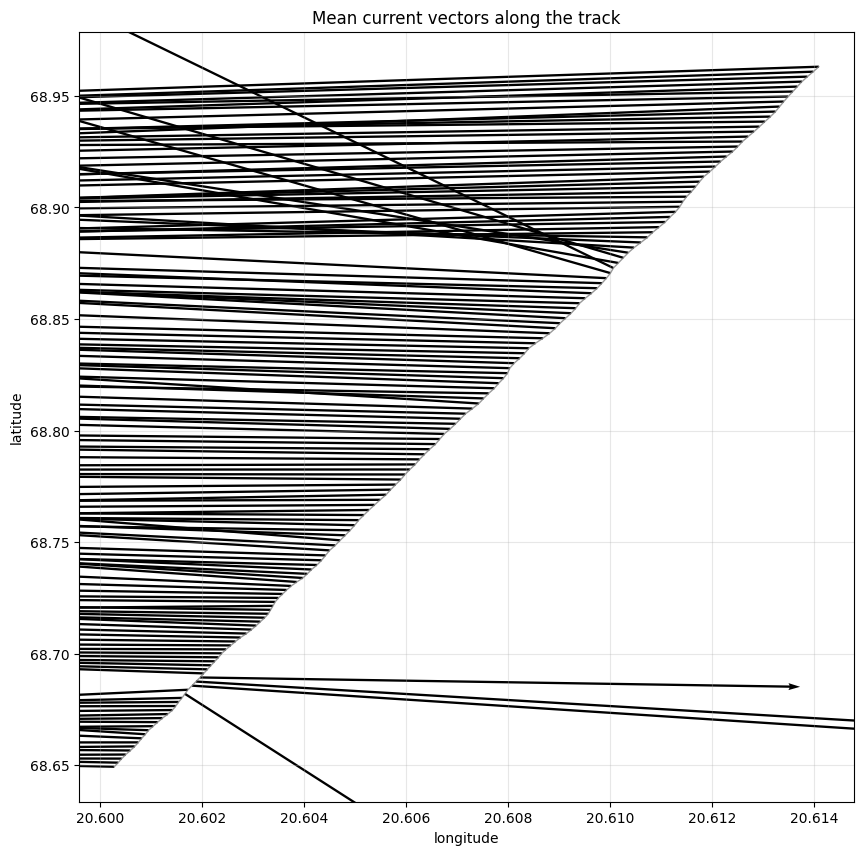

In [1]:
# Sample python script to read sample ADCP-Netcdf file generated in Simrad's EK80 software (v 2.0.1)


# libraries needed
import time
from datetime import UTC, datetime, timedelta
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import netCDF4 as Nc
import numpy as np

use_julian = True
try:
    from qs.os import (  # date to julian day conversion. My stuff, may not be available
        jul2str,
    )
except:
    use_julian = False


start = time.time()
base_dir = Path.cwd()
candidate_dirs = [
    base_dir,
    base_dir / "../files",
    base_dir / "EK80ACDP",
]

save_figure = True

nc_files = []
for candidate_dir in candidate_dirs:
    if candidate_dir.exists():
        nc_files.extend(sorted(candidate_dir.glob("*.nc")))

# Deduplicate while preserving order
seen = set()
unique_nc_files = []
for path in nc_files:
    if path not in seen:
        seen.add(path)
        unique_nc_files.append(path)

if not unique_nc_files:
    raise FileNotFoundError("No NetCDF files found in the expected locations.")

# Read all files and concatenate the time series along the first axis
vx_list, vy_list, vz_list = [], [], []
lon_list, lat_list, date_list = [], [], []
top_depths, depth_bins = [], []


def pad_to_max_columns(arr, n_cols):
    if arr.shape[1] == n_cols:
        return arr
    pad = n_cols - arr.shape[1]
    return np.pad(arr, ((0, 0), (0, pad)), mode="constant", constant_values=np.nan)


def convert_time_values(raw_values, units):
    if units is None:
        raise ValueError("Time units not found in NetCDF variable.")
    if "nanoseconds" in units:
        base_dt = datetime(1601, 1, 1, tzinfo=UTC)
        return np.array(
            [base_dt + timedelta(microseconds=int(v) // 1000) for v in raw_values],
            dtype=object,
        )
    return Nc.num2date(raw_values, units=units, calendar="gregorian")


for nc_path in unique_nc_files:
    with Nc.Dataset(str(nc_path)) as nc_obj:
        vx_arr = np.vstack(
            nc_obj[
                "/Sonar/Beam_group1/ADCP/Mean_current/current_velocity_geographical_east"
            ]
        )
        vy_arr = np.vstack(
            nc_obj[
                "/Sonar/Beam_group1/ADCP/Mean_current/current_velocity_geographical_north"
            ]
        )
        vz_arr = np.vstack(
            nc_obj[
                "/Sonar/Beam_group1/ADCP/Mean_current/current_velocity_geographical_down"
            ]
        )
        vx_list.append(vx_arr)
        vy_list.append(vy_arr)
        vz_list.append(vz_arr)
        lon_list.append(
            nc_obj["/Sonar/Beam_group1/ADCP/Mean_current/mean_platform_longitude"][:]
        )
        lat_list.append(
            nc_obj["/Sonar/Beam_group1/ADCP/Mean_current/mean_platform_latitude"][:]
        )

        time_var = nc_obj["/Sonar/Beam_group1/ADCP/Mean_current/mean_time"]
        date_arr = convert_time_values(time_var[:], getattr(time_var, "units", None))
        date_list.append(date_arr)

        top_depth = nc_obj["/Sonar/Beam_group1/ADCP/depth_first_sample_center"][:]
        depth_bin = nc_obj["/Sonar/Beam_group1/ADCP/vertical_sample_interval"][
            :
        ]  # very confusing name
        top_depths.append(float(top_depth[0]))
        depth_bins.append(float(depth_bin[0]))

max_bins = max(arr.shape[1] for arr in vx_list)
vx_list_padded = [pad_to_max_columns(arr, max_bins) for arr in vx_list]
vy_list_padded = [pad_to_max_columns(arr, max_bins) for arr in vy_list]
vz_list_padded = [pad_to_max_columns(arr, max_bins) for arr in vz_list]

vx = np.concatenate(vx_list_padded, axis=0)
vy = np.concatenate(vy_list_padded, axis=0)
vz = np.concatenate(vz_list_padded, axis=0)
lon = np.concatenate(lon_list)
lat = np.concatenate(lat_list)
date = np.concatenate(date_list)

print(f"Loaded {len(unique_nc_files)} files; combined shape: {vx.shape}")

# Keep full 2D fields for depth-time plots
vx_full = np.array(vx, copy=True)
vy_full = np.array(vy, copy=True)
vz_full = np.array(vz, copy=True)

# getting depth reference
print(
    f"Velocities loaded, n-columns={vx.shape[0]} n_rows={vx.shape[1]}. Now reading metadata"
)
depths = np.arange(max_bins) * np.median(depth_bins) + np.median(
    top_depths
)  # common depth axis for all files

# dates
if use_julian:
    print(f"Done, date range: start={jul2str(date[0])} stop={jul2str(date[-1])}")
else:
    print("Done. now doing graphics")

# vselecting test level and plotting
vx = vx[:, 3]
vy = vy[:, 3]
ix = np.isfinite(vx)
fig, ax = plt.subplots(2, 1, figsize=(15, 15))
ax[0].plot(vy[ix], c="blue")
ax[0].plot(vx[ix], c="red")
ax[0].set_title(
    f"velocities in bin 3. depth={depths[3]:4.2f}m,  East - red, North - blue"
)
ax[0].set_xlabel("sample no.")
ax[0].set_ylabel("current speed (m/s)")
ax[0].set_ylim(-0.5, 0.5)
elapsed_minutes = np.array(
    [(d - date[0]).total_seconds() / 60.0 for d in date], dtype=float
)
ax[1].plot(elapsed_minutes, c="magenta")

title = "Time duration (note the clock reset)"
if use_julian:
    title = (
        title
        + ". First ensemble on "
        + jul2str(date[0])
        + ", last "
        + jul2str(date[-1])
    )

ax[1].set_title(title)
ax[1].set_xlabel("sample no.")
ax[1].set_ylabel("time (minutes since first sample)")

# save figure
if save_figure:
    output_dir = Path(unique_nc_files[0]).parent
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_dir / "selectedBin.png")
else:
    plt.show()

# New figure: depth-time panels for vx, vy, and vz
x_time = mdates.date2num(date)
fig2, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)
fields = [("vx", vx_full), ("vy", vy_full), ("vz", vz_full)]

for ax, (name, data) in zip(axes, fields):
    img = ax.pcolormesh(
        x_time,
        depths,
        np.ma.masked_invalid(data.T),
        cmap="cmo.balance",
        vmin=-0.3,
        vmax=0.3,
        shading="auto",
    )
    ax.set_title(f"{name} versus time and depth")
    ax.set_ylabel("depth (m)")
    ax.set_ylim(depths[-1], 0)
    cbar = fig2.colorbar(img, ax=ax, pad=0.03)
    cbar.set_label(f"{name} (m/s)")

for ax in axes:
    ax.xaxis_date()
    ax.tick_params(axis="x", rotation=45)
fig2.autofmt_xdate()
axes[-1].set_xlabel("time (date and hour)")
fig2.suptitle("Velocity components by time and depth")
fig2.tight_layout(rect=[0, 0, 1, 0.98])

if save_figure:
    fig2.savefig(output_dir / "HovmollerSections.png")
else:
    plt.show()

# Map figure with quiver arrows along the trajectory
lon = np.asarray(lon)
lat = np.asarray(lat)

mask = (
    np.isfinite(lon)
    & np.isfinite(lat)
    & np.isfinite(vx_full[:, 0])
    & np.isfinite(vy_full[:, 0])
)
lon_plot = lon[mask]
lat_plot = lat[mask]
lon_plot = -lon_plot
u_plot = vy_full[mask, 0]
v_plot = vx_full[mask, 0]

step = max(1, len(lon_plot) // 150)
lon_plot = lon_plot[::step]
lat_plot = lat_plot[::step]
u_plot = u_plot[::step]
v_plot = v_plot[::step]

fig3, ax3 = plt.subplots(figsize=(10, 10))
ax3.plot(lon_plot, lat_plot, color="gray", lw=1, alpha=0.8)
ax3.quiver(
    lon_plot,
    lat_plot,
    u_plot,
    v_plot,
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.003,
)
ax3.set_title("Mean current vectors along the track")
ax3.set_xlabel("longitude")
ax3.set_ylabel("latitude")
ax3.grid(True, alpha=0.3)

if save_figure:
    fig3.savefig(output_dir / "Velmaps.png")
else:
    plt.show()

stop = time.time()
print(f"time elapsed = {stop - start} seconds")